# Bachelorproef — POC: Automatische detectie van open/gesloten status van supermarkten

**Auteur:** Maxim Van Der Schueren  
**Academiejaar:** 2025–2026   

---

**Labelstrategie:**
- `is_active = 1` → open
- `is_active = 0` → gesloten (scraper was actief maar registreerde POI als inactief)
- `is_deleted = 1` → extra feature, **niet** als label

---
## 0. Configuratie & bibliotheken

Pas `DATA_PATH` aan om te wisselen tussen de Delhaize-testset en de volledige dataset.

In [247]:
DATA_PATH   = "../../data accurat/Data_accurat.csv"  
MODEL_DIR   = "./models"         
RANDOM_SEED = 42
TEST_SIZE   = 0.2

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
import joblib

import xgboost as xgb

---
## 1. Data inladen

In [248]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Geladen: {df_raw.shape[0]:,} rijen × {df_raw.shape[1]} kolommen")
df_raw.head(3)

Geladen: 1,337,279 rijen × 51 kolommen


,id,poi_id,status_start,status_end,is_active,inserted_at_history,updated_at_history,poi_id.history,name,street,...,pause_stop,stop.oh,appointment,closed,ok,inserted_at.oh,updated_at.oh,date,start_valid,end_valid
0,597060,18543,2018-05-04,NaN,1,2022-11-30 15:58:01,2022-11-30 15:58:01,18543,Albert Heijn,De Koel,...,NaN,20:00:00,NaN,0.0,1,2020-06-03 08:40:55,2022-05-17 15:42:24,NaN,NaN,NaN
1,597060,18543,2018-05-04,NaN,1,2022-11-30 15:58:01,2022-11-30 15:58:01,18543,Albert Heijn,De Koel,...,NaN,11:45:00,NaN,0.0,1,2025-06-25 17:34:19,2025-06-25 17:34:19,NaN,2022-04-18,2022-04-18
2,597060,18543,2018-05-04,NaN,1,2022-11-30 15:58:01,2022-11-30 15:58:01,18543,Albert Heijn,De Koel,...,NaN,11:45:00,NaN,0.0,1,2025-06-25 18:39:06,2025-06-25 18:39:06,NaN,2022-06-06,2022-06-06


In [249]:
df_raw.dtypes

id                       int64
poi_id                   int64
status_start            object
status_end              object
is_active                int64
inserted_at_history     object
updated_at_history      object
poi_id.history           int64
name                    object
street                  object
nbr                     object
box                     object
zip                     object
city                    object
country                 object
priority                object
source                  object
source_id               object
point                   object
polygon                 object
is_active.history        int64
visit                    int64
work                   float64
main_category_id       float64
brand_id                object
inserted_at.poi         object
updated_at.poi          object
district_id             object
client_id              float64
description             object
is_sensitive             int64
pass                    object
poi_pare

In [250]:
# Ontbrekende waarden per kolom
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "percentage": missing_pct})
missing_df[missing_df["missing"] > 0].sort_values("percentage", ascending=False)

,missing,percentage
district_id,1337267,100.00
main_category_id,1337193,99.99
poi_parent_id,1337193,99.99
client_id,1336755,99.96
description,1329773,99.44
date,1328796,99.37
pause_start,1323807,98.99
pause_stop,1323670,98.98
appointment,1319288,98.65
box,1288024,96.32


In [251]:
df = df_raw.copy()

# Kolommen met 100% ontbrekende waarden verwijderen 
volledig_leeg = df.columns[df.isnull().mean() == 1.0].tolist()
if volledig_leeg:
    df.drop(columns=volledig_leeg, inplace=True)
    print(f"Verwijderde kolommen: {volledig_leeg}")

In [252]:
# Datumkolommen parsen
for col in ["status_start", "status_end", "inserted_at.poi", "updated_at_history", "start_valid", "end_valid"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
df.dtypes

id                              int64
poi_id                          int64
status_start           datetime64[ns]
status_end             datetime64[ns]
is_active                       int64
inserted_at_history            object
updated_at_history     datetime64[ns]
poi_id.history                  int64
name                           object
street                         object
nbr                            object
box                            object
zip                            object
city                           object
country                        object
priority                       object
source                         object
source_id                      object
point                          object
polygon                        object
is_active.history               int64
visit                           int64
work                          float64
main_category_id              float64
brand_id                       object
inserted_at.poi        datetime64[ns]
updated_at.p

In [253]:
# Numerieke kolommen saneren
numerieke_cols = [
    "day_of_week", "visit", "work", "closed", "ok",
    "is_deleted", "is_sensitive", "is_reserved_poi", "cluster",
    "brand_id", "priority"
]
for col in numerieke_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 2. Data analyse

### 2.1 Verdeling open / gesloten

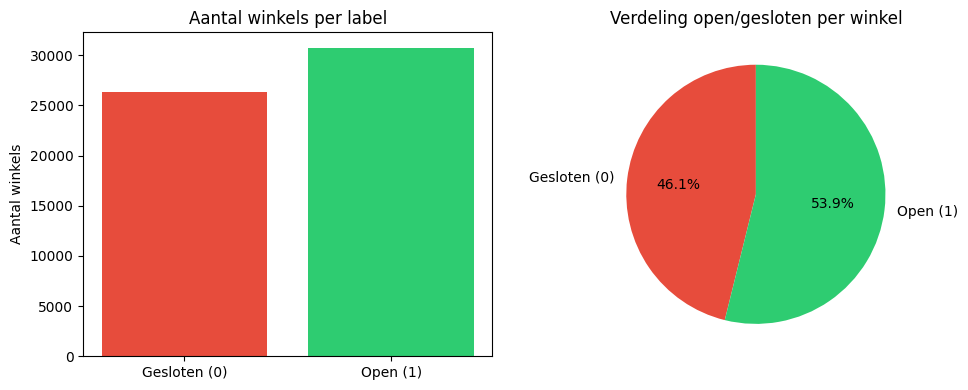

           aantal  percentage
is_active                    
0.0         26336       46.14
1.0         30740       53.85


In [254]:
df_basis = pd.read_csv("../../data accurat/Basisinfo2.csv", low_memory=False, delimiter=";")

label_counts = df_basis["is_active"].value_counts().sort_index()
label_pct    = label_counts / len(df_basis) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Gesloten (0)", "Open (1)"], label_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Aantal winkels per label")
axes[0].set_ylabel("Aantal winkels")

axes[1].pie(label_counts.values, labels=["Gesloten (0)", "Open (1)"],
            autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"], startangle=90)
axes[1].set_title("Verdeling open/gesloten per winkel")

plt.tight_layout()
plt.savefig("./Grafieken/verdeling_status.png", dpi=300, bbox_inches="tight")
plt.show()

print(label_counts.to_frame("aantal").assign(percentage=label_pct.round(2)))

### 2.2 Verdeling per merk 

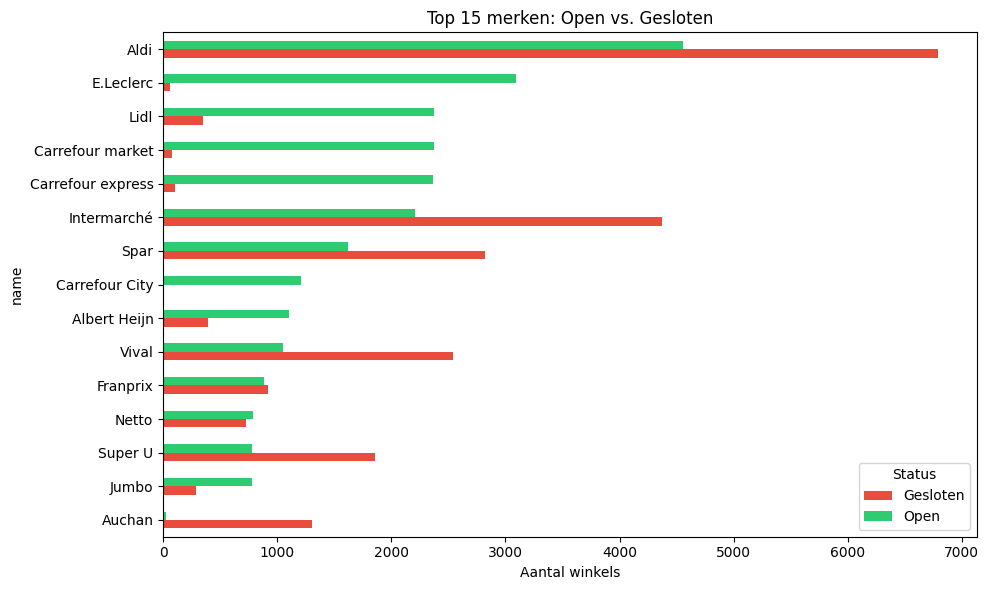

In [255]:
top_brands = df_basis["name"].value_counts().nlargest(15).index
brand_status = (df_basis[df_basis["name"].isin(top_brands)]
                .groupby("name")["is_active"]
                .value_counts()
                .unstack(fill_value=0)
                .rename(columns={0: "Gesloten", 1: "Open"}))

brand_status.sort_values("Open").plot(kind="barh", figsize=(10, 6), color=["#e74c3c", "#2ecc71"])
plt.xlabel("Aantal winkels")
plt.title("Top 15 merken: Open vs. Gesloten")
plt.legend(title="Status")
plt.tight_layout()
plt.savefig("./Grafieken/top_brands.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.3. Verdeling per land

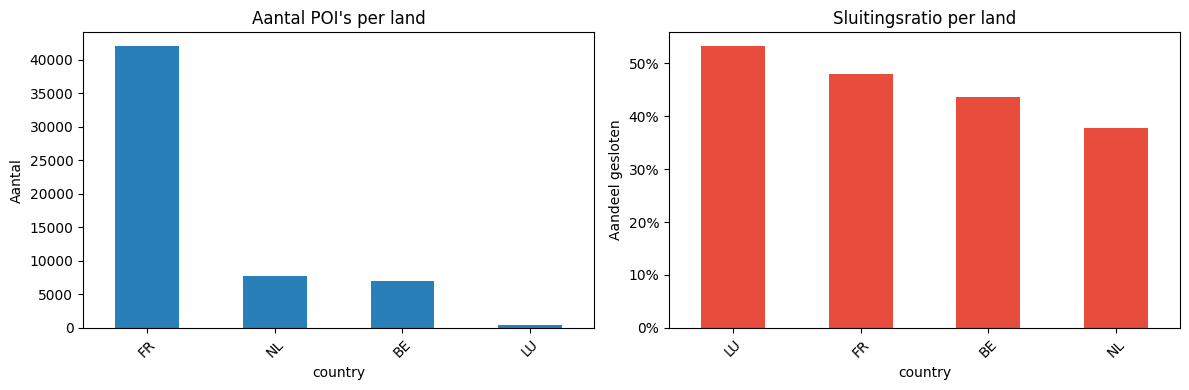

In [256]:
land_counts = df_basis["country"].value_counts()
land_status = (df_basis.groupby("country")["is_active"]
               .value_counts(normalize=True)
               .unstack(fill_value=0)
               .rename(columns={0: "Gesloten", 1: "Open"})
               .sort_values("Gesloten", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
land_counts.plot(kind="bar", ax=axes[0], color="#2980b9")
axes[0].set_title("Aantal POI's per land")
axes[0].set_ylabel("Aantal")
axes[0].tick_params(axis="x", rotation=45)

land_status["Gesloten"].plot(kind="bar", ax=axes[1], color="#e74c3c")
axes[1].set_title("Sluitingsratio per land")
axes[1].set_ylabel("Aandeel gesloten")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("./Grafieken/land_status.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. Feature engineering


In [ ]:
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [258]:
def tijd_naar_minuten(tijdstr):
    try:
        parts = str(tijdstr).split(":")
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return 0

df["heeft_openingsuren"] = (df["start.oh"].notna() & df["stop.oh"].notna()).astype(int)
df["start_min"] = df["start.oh"].apply(lambda x: tijd_naar_minuten(x) if pd.notna(x) else np.nan)
df["stop_min"]  = df["stop.oh"].apply(lambda x: tijd_naar_minuten(x) if pd.notna(x) else np.nan)
df["verwachte_openingsduur_min"] = df["stop_min"] - df["start_min"]

In [259]:
df["is_deleted"] = df["is_deleted"].fillna(0).astype(int)

In [260]:
le = LabelEncoder()
df["brand_id_enc"] = le.fit_transform(df["name"].astype(str))
df["country_enc"]  = le.fit_transform(df["country"].astype(str))

In [ ]:
df = df.sort_values(['poi_id', 'updated_at_history'])
df['poi_leeftijd_maanden'] = ((df['updated_at_history'] - df.groupby('poi_id')['updated_at_history'].transform('min')).dt.days / 30).round()
df["n_observaties_poi"] = df.groupby("poi_id")["poi_id"].transform("count")

In [ ]:
FEATURE_COLS = [
    col for col in [ 
        "is_weekend","day_of_week", "start_min", "stop_min", "heeft_openingsuren",
        "verwachte_openingsduur_min", "brand_id_enc", "country_enc", "poi_leeftijd_maanden",
        "n_observaties_poi", "is_deleted",
    ]
    if col in df.columns
]

TARGET_COL = "is_active"

---
## 4. Train/test-splitsing

In [ ]:
df_model = df[FEATURE_COLS + [TARGET_COL, "updated_at_history"]].dropna(subset=[TARGET_COL])

df_model[FEATURE_COLS] = df_model[FEATURE_COLS].fillna(df_model[FEATURE_COLS].median(numeric_only=True))

X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL].astype(int)

# Gestratificeerde split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Label-verdeling train — open: {y_train.mean():.2%}")
print(f"Label-verdeling test  — open: {y_test.mean():.2%}")

Train: 1,069,823 | Test: 267,456
Label-verdeling train — open: 74.67%
Label-verdeling test  — open: 74.67%


---
## 5. Hulpfuncties

In [265]:
def evalueer_model(naam, model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else None 

    print(f"\n{'='*50}")
    print(f"Model: {naam}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Gesloten", "Open"]))

    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                                   display_labels=["Gesloten", "Open"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"Confusion matrix — {naam}")
    plt.tight_layout()
    plt.savefig(f"./Grafieken/conv_matrix_{naam.lower().replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()

    return {"model": naam, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": auc} 

In [266]:
def plot_feature_importance(naam, model, feature_names, top_n=15):
    importances = model.feature_importances_
    idx = np.argsort(importances)[-top_n:]

    plt.figure(figsize=(8, max(4, top_n * 0.35)))
    plt.barh(np.array(feature_names)[idx], importances[idx], color="#2980b9")
    plt.xlabel("Feature importance")
    plt.title(f"Top {top_n} features — {naam}")
    plt.tight_layout()
    plt.savefig(f"./Grafieken/feature_importance_{naam.lower().replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [267]:
resultaten = [] 

---
## 6. Model 1 — Random Forest

In [268]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', min_samples_leaf=5,
                       n_estimators=200, n_jobs=-1, random_state=42)


Model: Random Forest
Accuracy : 0.7820
Precision: 0.9402
Recall   : 0.7561
F1-score : 0.8382
AUC      : 0.8611
              precision    recall  f1-score   support

    Gesloten       0.54      0.86      0.67     67759
        Open       0.94      0.76      0.84    199697

    accuracy                           0.78    267456
   macro avg       0.74      0.81      0.75    267456
weighted avg       0.84      0.78      0.79    267456



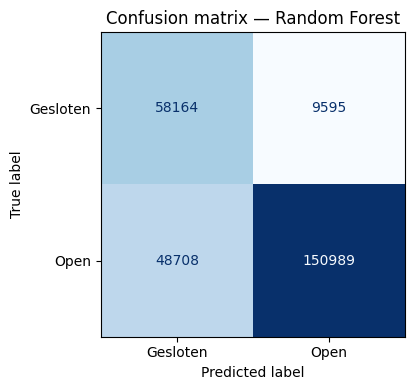

In [269]:
rf_metrics = evalueer_model("Random Forest", rf, X_test, y_test)
resultaten.append(rf_metrics)

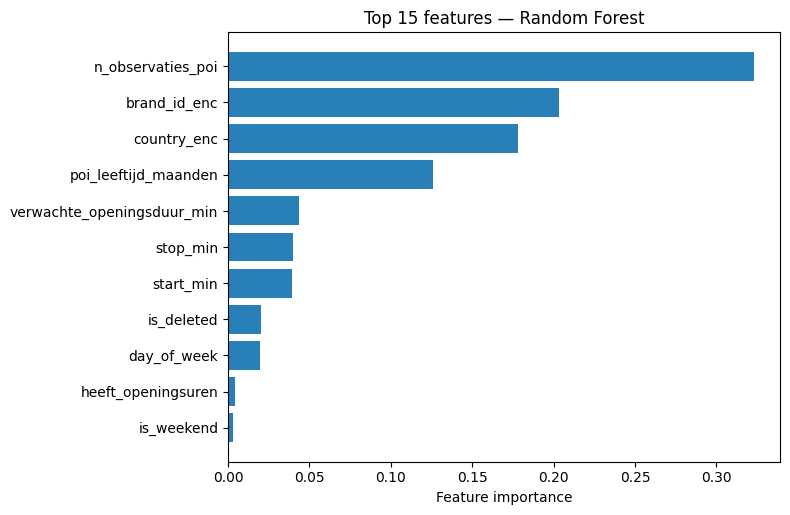

In [270]:
plot_feature_importance("Random Forest", rf, FEATURE_COLS)

In [271]:
joblib.dump(rf, os.path.join(MODEL_DIR, "random_forest.joblib"))

['./models\\random_forest.joblib']

---
## 7. Model 2 — XGBoost

In [272]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pw  = neg / pos if pos > 0 else 1

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)


Model: XGBoost
Accuracy : 0.7610
Precision: 0.9235
Recall   : 0.7413
F1-score : 0.8224
AUC      : 0.8555
              precision    recall  f1-score   support

    Gesloten       0.52      0.82      0.63     67759
        Open       0.92      0.74      0.82    199697

    accuracy                           0.76    267456
   macro avg       0.72      0.78      0.73    267456
weighted avg       0.82      0.76      0.77    267456



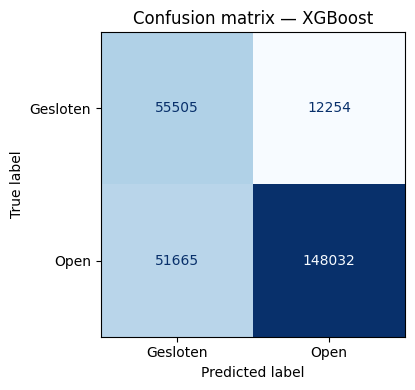

In [273]:
xgb_metrics = evalueer_model("XGBoost", xgb_model, X_test, y_test)
resultaten.append(xgb_metrics)

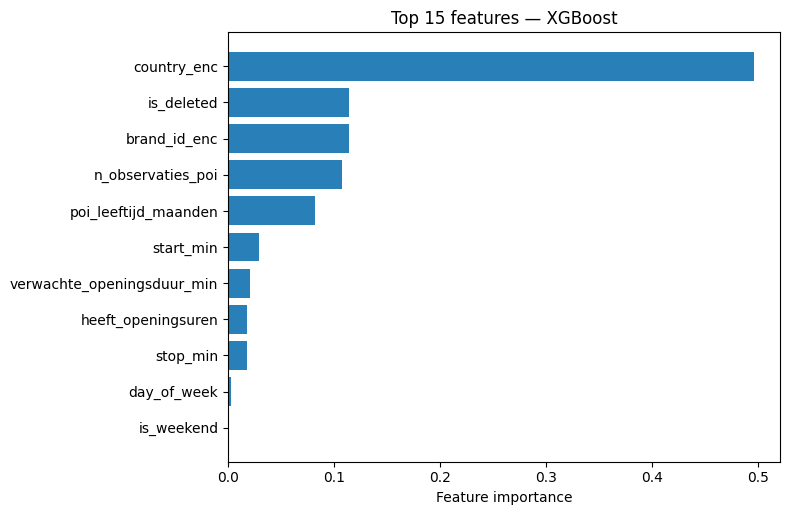

In [274]:
plot_feature_importance("XGBoost", xgb_model, FEATURE_COLS)

In [275]:
joblib.dump(xgb_model, os.path.join(MODEL_DIR, "xgboost.joblib"))

['./models\\xgboost.joblib']

## 8. Model 3 — Logistic Regression

In [276]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=RANDOM_SEED
)
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)


Model: Logistic Regression
Accuracy : 0.6605
Precision: 0.8113
Recall   : 0.7106
F1-score : 0.7576
AUC      : 0.6484
              precision    recall  f1-score   support

    Gesloten       0.38      0.51      0.43     67759
        Open       0.81      0.71      0.76    199697

    accuracy                           0.66    267456
   macro avg       0.59      0.61      0.60    267456
weighted avg       0.70      0.66      0.68    267456



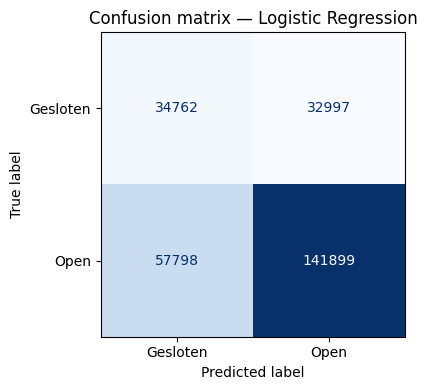

In [277]:
lr_metrics = evalueer_model("Logistic Regression", lr, X_test, y_test)
resultaten.append(lr_metrics)

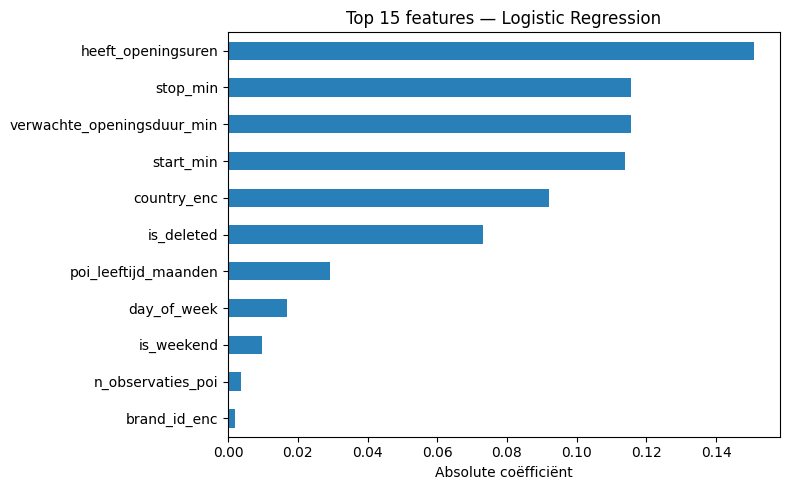

In [ ]:
coef = pd.Series(lr.coef_[0], index=FEATURE_COLS).abs().sort_values(ascending=True)
coef.tail(15).plot(kind="barh", figsize=(8, 5), color="#2980b9")
plt.xlabel("Absolute coëfficiënt")
plt.title("Top 15 features — Logistic Regression")
plt.tight_layout()
plt.savefig("./Grafieken/feature_importance_lr.png", dpi=300, bbox_inches="tight")
plt.show()

In [279]:
joblib.dump(lr, os.path.join(MODEL_DIR, "logistic_regression.joblib"))

['./models\\logistic_regression.joblib']

---
## 9. Modelvergelijking

In [280]:
df_resultaten = pd.DataFrame(resultaten)
df_resultaten = df_resultaten.drop_duplicates(subset=["model"])
df_resultaten = df_resultaten.set_index("model")
df_resultaten = df_resultaten.rename(columns={
    "accuracy" : "Accuracy",
    "precision": "Precision",
    "recall"   : "Recall",
    "f1"       : "F1-score",
    "auc"      : "AUC"
})

display(df_resultaten.style.format("{:.4f}"))

,Accuracy,Precision,Recall,F1-score,AUC
model,,,,,
Random Forest,0.7820,0.9402,0.7561,0.8382,0.8611
XGBoost,0.7610,0.9235,0.7413,0.8224,0.8555
Logistic Regression,0.6605,0.8113,0.7106,0.7576,0.6484


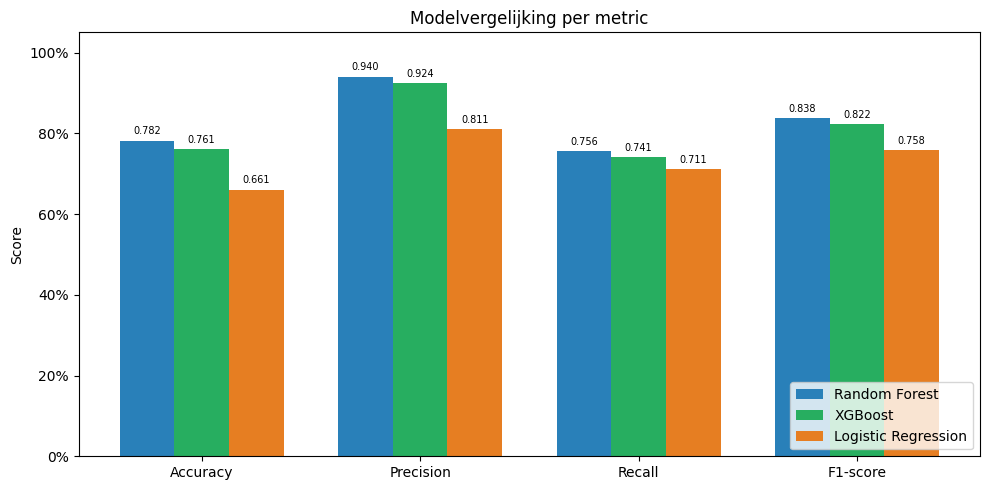

In [281]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
x       = np.arange(len(metrics))
width   = 0.25
kleuren = ["#2980b9", "#27ae60", "#e67e22"]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (naam, rij) in enumerate(df_resultaten.iterrows()):
    ax.bar(x + i * width, rij[metrics].values, width, label=naam, color=kleuren[i % len(kleuren)])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Modelvergelijking per metric")
ax.legend(loc="lower right")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# Waarde-labels boven de balken
for patch in ax.patches:
    h = patch.get_height()
    ax.annotate(f"{h:.3f}",
                xy=(patch.get_x() + patch.get_width() / 2, h),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("./Grafieken/modelvergelijking.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Uitbreiding: Synthetische Mobiliteitsdata op Basisinfo

In [282]:
df_mob_basis = df_basis.copy()

# Categorische kolommen encoderen
le = LabelEncoder()
for col in ["name", "country", "source", "priority"]:
    if col in df_mob_basis.columns:
        df_mob_basis[f"{col}_enc"] = le.fit_transform(
            df_mob_basis[col].fillna("onbekend").astype(str)
        )

# Numerieke kolommen
for col in ["brand_id", "main_category_id", "cluster","is_deleted", "is_sensitive", "is_reserved_poi", "visit", "work"]:
    if col in df_mob_basis.columns:
        df_mob_basis[col] = pd.to_numeric(df_mob_basis[col], errors="coerce")

In [283]:
if "polygon" in df_mob_basis.columns:
    df_mob_basis["heeft_polygon"] = df_mob_basis["polygon"].notna().astype(int)
if "source_id" in df_mob_basis.columns:
    df_mob_basis["heeft_source_id"] = df_mob_basis["source_id"].notna().astype(int)

In [284]:
for col in ["inserted_at", "updated_at"]:
    if col in df_mob_basis.columns:
        df_mob_basis[col] = pd.to_datetime(df_mob_basis[col], errors="coerce")

if "inserted_at" in df_mob_basis.columns:
    df_mob_basis["poi_leeftijd_dagen"] = (
        df_mob_basis["inserted_at"].max() - df_mob_basis["inserted_at"]
    ).dt.days

if "updated_at" in df_mob_basis.columns:
    df_mob_basis["dagen_sinds_update"] = (
        df_mob_basis["updated_at"].max() - df_mob_basis["updated_at"]
    ).dt.days

In [285]:
WEEK_PATROON    = np.array([0.75, 0.80, 0.82, 0.85, 1.00, 0.95, 0.45])
BASIS_BEZOEKERS = 250
DECAY_WEKEN     = 10
N_WEKEN         = 26   # half jaar

mob_rng = np.random.default_rng(RANDOM_SEED)

In [286]:
def genereer_bezoekersprofiel(poi_id, is_actief, n_weken=N_WEKEN,
                               decay_weken=DECAY_WEKEN, basis=BASIS_BEZOEKERS):
    records    = []
    poi_factor = mob_rng.uniform(0.7, 1.3)

    for week in range(n_weken):
        for dag in range(7):
            mu_basis = basis * poi_factor * WEEK_PATROON[dag]

            if is_actief:
                fase      = "stabiel"
                bezoekers = max(0, int(mob_rng.normal(mu_basis, mu_basis * 0.40)))
            else:
                weken_tot_sluiting = n_weken - week
                if weken_tot_sluiting > decay_weken:
                    fase      = "stabiel"
                    bezoekers = max(0, int(mob_rng.normal(mu_basis, mu_basis * 0.40)))
                elif weken_tot_sluiting > 2:   # ← was > 0
                    fase         = "decay"
                    decay_factor = weken_tot_sluiting / decay_weken
                    mu_decay     = mu_basis * decay_factor
                    bezoekers    = max(0, int(mob_rng.normal(mu_decay, mu_decay * 0.50 + 5)))
                else:                          # laatste 2 weken = gesloten
                    fase      = "gesloten"
                    bezoekers = max(0, int(mob_rng.normal(2, 3)))

            records.append({"poi_id": poi_id, "week": week, "dag": dag, "bezoekers": bezoekers, "fase": fase})
    return pd.DataFrame(records)

In [287]:
# Test met één POI of de ruis groter is
test_profiel = genereer_bezoekersprofiel(999, is_actief=False)
print(test_profiel.groupby("fase")["bezoekers"].describe())

          count        mean         std   min     25%    50%     75%    max
fase                                                                       
decay      56.0  150.160714  117.774017   0.0   64.75  112.0  198.25  506.0
gesloten   14.0    1.714286    1.898525   0.0    0.00    1.5    2.00    6.0
stabiel   112.0  227.758929   89.772008  54.0  152.00  221.5  302.00  432.0


In [288]:
open_ids     = df_mob_basis[df_mob_basis["is_active"] == 1]["id"].tolist()
gesloten_ids = df_mob_basis[df_mob_basis["is_active"] == 0]["id"].tolist()

In [289]:
alle_profielen = []
for poi_id in open_ids:
    alle_profielen.append(genereer_bezoekersprofiel(poi_id, is_actief=True))
for poi_id in gesloten_ids:
    alle_profielen.append(genereer_bezoekersprofiel(poi_id, is_actief=False))

df_mob_raw = pd.concat(alle_profielen, ignore_index=True)
print(f"Gegenereerd: {len(df_mob_raw):,} dagelijkse records")

Gegenereerd: 10,387,832 dagelijkse records


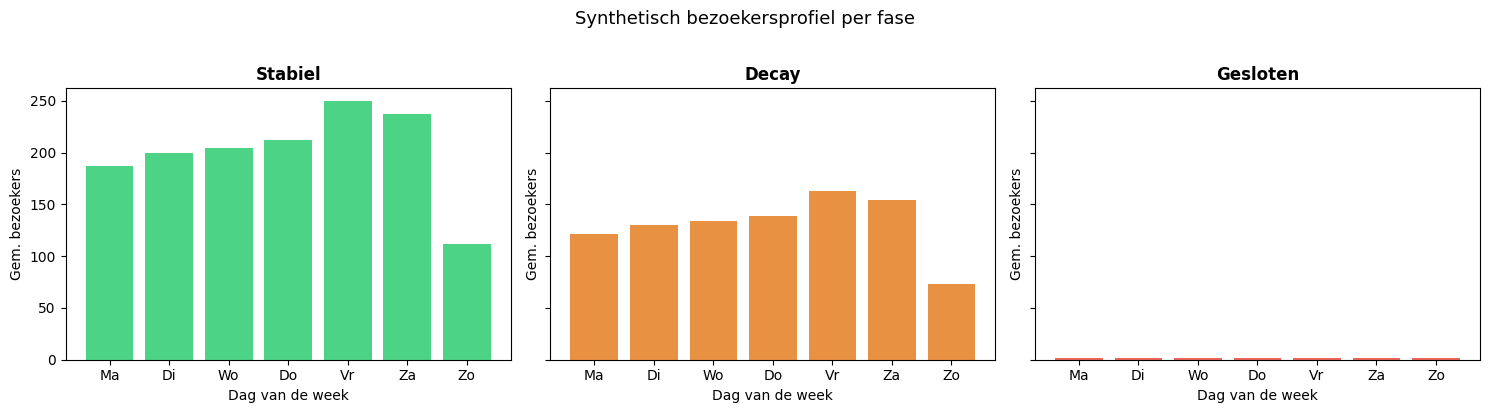

In [290]:
dag_labels = ["Ma", "Di", "Wo", "Do", "Vr", "Za", "Zo"]
fases      = ["stabiel", "decay", "gesloten"]
kleuren    = ["#2ecc71", "#e67e22", "#e74c3c"]

# Filter enkel fases die data bevatten
fases_aanwezig = [(f, k) for f, k in zip(fases, kleuren) if len(df_mob_raw[df_mob_raw["fase"] == f]) > 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (fase, kleur) in zip(axes, fases_aanwezig):
    subset = df_mob_raw[df_mob_raw["fase"] == fase]
    gem    = subset.groupby("dag")["bezoekers"].mean()
    ax.bar(dag_labels, gem.values, color=kleur, alpha=0.85)
    ax.set_title(fase.capitalize(), fontsize=12, fontweight="bold")
    ax.set_xlabel("Dag van de week")
    ax.set_ylabel("Gem. bezoekers")

plt.suptitle("Synthetisch bezoekersprofiel per fase", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("./Grafieken/mob_weekprofiel_per_fase.png", dpi=300, bbox_inches="tight")
plt.show()

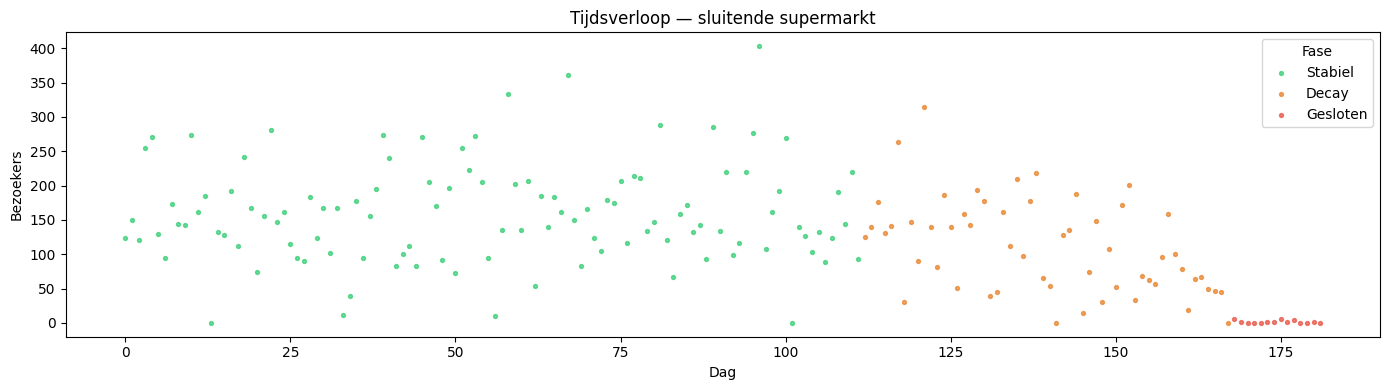

In [291]:
voorbeeld_df = df_mob_raw[df_mob_raw["poi_id"] == gesloten_ids[0]].copy()
voorbeeld_df["tijdstap"] = voorbeeld_df["week"] * 7 + voorbeeld_df["dag"]

fig, ax = plt.subplots(figsize=(14, 4))
for fase, kleur in zip(fases, kleuren):
    s = voorbeeld_df[voorbeeld_df["fase"] == fase]
    ax.scatter(s["tijdstap"], s["bezoekers"], color=kleur, s=8,
               label=fase.capitalize(), alpha=0.7)
ax.set_xlabel("Dag")
ax.set_ylabel("Bezoekers")
ax.set_title("Tijdsverloop — sluitende supermarkt")
ax.legend(title="Fase")
plt.tight_layout()
plt.savefig("./Grafieken/mob_tijdsverloop.png", dpi=300, bbox_inches="tight")
plt.show()

In [304]:
df_mob_sorted = df_mob_raw.sort_values(["poi_id", "week", "dag"])

def bereken_trend(serie):
    if len(serie) < 2:
        return 0.0
    return float(np.polyfit(np.arange(len(serie)), serie, 1)[0])

agg_per_poi = (
    df_mob_sorted.groupby("poi_id")["bezoekers"]
    .agg(gem_bezoekers = "mean", std_bezoekers = "std", max_bezoekers = "max", pct_nul_dagen = lambda x: (x == 0).mean())
    .reset_index()
)

trend_per_poi = df_mob_sorted.groupby("poi_id")["bezoekers"].apply(bereken_trend).reset_index().rename(columns={"bezoekers": "trend_coefficient"})

df_mob_features = agg_per_poi.merge(trend_per_poi, on="poi_id")

# Koppelen aan basisinfo via id
df_uitgebreid = df_mob_basis.merge(df_mob_features.rename(columns={"poi_id": "id"}), on="id", how="left")

MOB_COLS = ["gem_bezoekers", "std_bezoekers", "max_bezoekers"]

print(f"Gekoppeld: {df_uitgebreid.shape[0]:,} POI's")

Gekoppeld: 57,082 POI's


In [293]:
FEATURE_COLS_BASIS = [
    col for col in [
        "name_enc", "country_enc", "source_enc", "priority_enc",
        "brand_id", "main_category_id", "cluster",
        "is_sensitive", "is_reserved_poi",
        "visit", "work", "heeft_polygon", "heeft_source_id",
        "poi_leeftijd_dagen", "dagen_sinds_update",
    ] if col in df_uitgebreid.columns
]

FEATURE_COLS_MOB = FEATURE_COLS_BASIS + MOB_COLS
TARGET_COL = "is_active"

In [294]:
df_m = df_uitgebreid[FEATURE_COLS_MOB + [TARGET_COL]].dropna(subset=[TARGET_COL])
df_m[FEATURE_COLS_MOB] = df_m[FEATURE_COLS_MOB].fillna(
    df_m[FEATURE_COLS_MOB].median(numeric_only=True)
)

X_m = df_m[FEATURE_COLS_MOB]
y_m = df_m[TARGET_COL].astype(int)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m, y_m, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_m
)

In [295]:
# Verwijder oude modellen expliciet
rf_mob  = None
xgb_mob = None
lr_mob  = None

### Model 1: Random Forest


Model: Random Forest (mobiliteit)
Accuracy : 0.9989
Precision: 0.9990
Recall   : 0.9990
F1-score : 0.9990
AUC      : 1.0000
              precision    recall  f1-score   support

    Gesloten       1.00      1.00      1.00      5268
        Open       1.00      1.00      1.00      6148

    accuracy                           1.00     11416
   macro avg       1.00      1.00      1.00     11416
weighted avg       1.00      1.00      1.00     11416



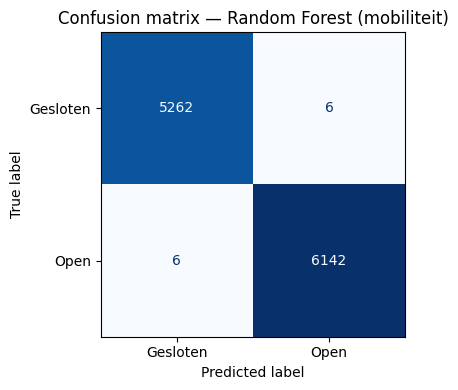

In [296]:
rf_mob = RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                 class_weight="balanced",
                                 random_state=RANDOM_SEED, n_jobs=-1)
rf_mob.fit(X_train_m, y_train_m)
rf_mob_metrics = evalueer_model("Random Forest (mobiliteit)", rf_mob, X_test_m, y_test_m)
resultaten.append(rf_mob_metrics)

### Model 2: XGBoost


Model: XGBoost (mobiliteit)
Accuracy : 0.9996
Precision: 1.0000
Recall   : 0.9993
F1-score : 0.9997
AUC      : 1.0000
              precision    recall  f1-score   support

    Gesloten       1.00      1.00      1.00      5268
        Open       1.00      1.00      1.00      6148

    accuracy                           1.00     11416
   macro avg       1.00      1.00      1.00     11416
weighted avg       1.00      1.00      1.00     11416



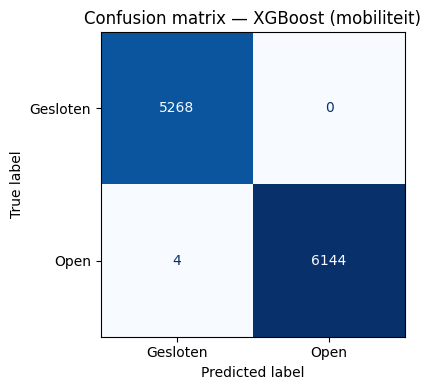

In [297]:
neg_m, pos_m = (y_train_m == 0).sum(), (y_train_m == 1).sum()
xgb_mob = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              scale_pos_weight=neg_m/pos_m,
                              eval_metric="logloss",
                              random_state=RANDOM_SEED, n_jobs=-1)
xgb_mob.fit(X_train_m, y_train_m)
xgb_mob_metrics = evalueer_model("XGBoost (mobiliteit)", xgb_mob, X_test_m, y_test_m)
resultaten.append(xgb_mob_metrics)

### Model 3: Logistic Regression


Model: Logistic Regression (mobiliteit)
Accuracy : 0.9992
Precision: 0.9997
Recall   : 0.9989
F1-score : 0.9993
AUC      : 1.0000
              precision    recall  f1-score   support

    Gesloten       1.00      1.00      1.00      5268
        Open       1.00      1.00      1.00      6148

    accuracy                           1.00     11416
   macro avg       1.00      1.00      1.00     11416
weighted avg       1.00      1.00      1.00     11416



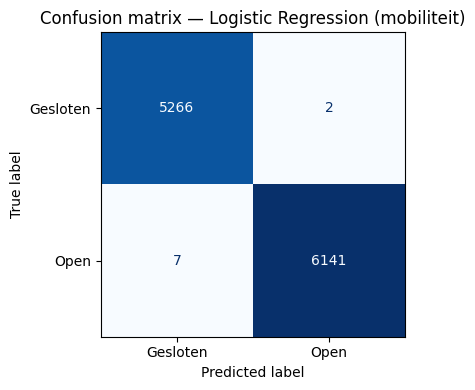

In [298]:
lr_mob = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_SEED)
lr_mob.fit(X_train_m, y_train_m)
lr_mob_metrics = evalueer_model("Logistic Regression (mobiliteit)", lr_mob, X_test_m, y_test_m)
resultaten.append(lr_mob_metrics)

In [299]:
df_eind = pd.DataFrame(resultaten).drop_duplicates(subset=["model"]).set_index("model")
df_eind = df_eind.rename(columns={"accuracy":"Accuracy","precision":"Precision", "recall":"Recall","f1":"F1-score"})
display(df_eind.style.format("{:.4f}").highlight_max(axis=0, color="#d5f5e3"))

,Accuracy,Precision,Recall,F1-score,auc
model,,,,,
Random Forest,0.7820,0.9402,0.7561,0.8382,0.8611
XGBoost,0.7610,0.9235,0.7413,0.8224,0.8555
Logistic Regression,0.6605,0.8113,0.7106,0.7576,0.6484
Random Forest (mobiliteit),0.9989,0.9990,0.9990,0.9990,1.0000
XGBoost (mobiliteit),0.9996,1.0000,0.9993,0.9997,1.0000
Logistic Regression (mobiliteit),0.9992,0.9997,0.9989,0.9993,1.0000


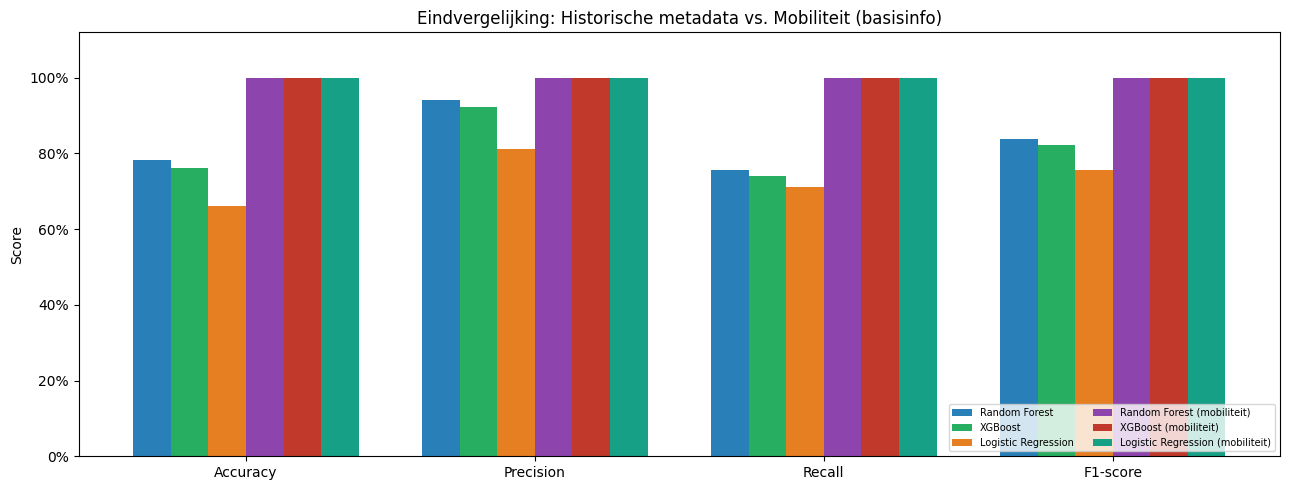

In [300]:
metrics_e = ["Accuracy", "Precision", "Recall", "F1-score"]
x_e       = np.arange(len(metrics_e))
width_e   = 0.13
kleuren_e = ["#2980b9","#27ae60","#e67e22","#8e44ad","#c0392b","#16a085"]

fig, ax = plt.subplots(figsize=(13, 5))
for i, (naam, rij) in enumerate(df_eind.iterrows()):
    ax.bar(x_e + i * width_e, rij[metrics_e].values, width_e, label=naam, color=kleuren_e[i % len(kleuren_e)])

ax.set_xticks(x_e + width_e * (len(df_eind) - 1) / 2)
ax.set_xticklabels(metrics_e)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Eindvergelijking: Historische metadata vs. Mobiliteit (basisinfo)")
ax.legend(loc="lower right", fontsize=7, ncol=2)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig("./Grafieken/eindvergelijking.png", dpi=300, bbox_inches="tight")
plt.show()